In [1]:
#telechargement des bibliotheques 

In [2]:
!pip install rdkit pandas numpy matplotlib seaborn scikit-learn

In [3]:
#charger de dataset 

In [4]:
import pandas as pd
# Charger le dataset ZINC 250k depuis le dossier local
df = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
print('Dimensions :', df.shape)
print('Colonnes :', df.columns.tolist())
print('Types :', df.dtypes)
df.head(10)

Dimensions : (249455, 4)
Colonnes : ['smiles', 'logP', 'qed', 'SAS']
Types : smiles     object
logP      float64
qed       float64
SAS       float64
dtype: object


,smiles,logP,qed,SAS
0,CC(C)(C)c1ccc2occ(CC(=O)Nc3ccccc3F)c2c1\n,5.05060,0.702012,2.084095
1,C[C@@H]1CC(Nc2cncc(-c3nncn3C)c2)C[C@@H](C)C1\n,3.11370,0.928975,3.432004
2,N#Cc1ccc(-c2ccc(O[C@@H](C(=O)N3CCCC3)c3ccccc3)...,4.96778,0.599682,2.470633
3,CCOC(=O)[C@@H]1CCCN(C(=O)c2nc(-c3ccc(C)cc3)n3c...,4.00022,0.690944,2.822753
4,N#CC1=C(SCC(=O)Nc2cccc(Cl)c2)N=C([O-])[C@H](C#...,3.60956,0.789027,4.035182
5,CC[NH+](CC)[C@](C)(CC)[C@H](O)c1cscc1Br\n,2.63740,0.824369,5.091438
6,COc1ccc(C(=O)N(C)[C@@H](C)C/C(N)=N/O)cc1O\n,0.99780,0.327297,2.852316
7,O=C(Nc1nc[nH]n1)c1cccnc1Nc1cccc(F)c1\n,2.33470,0.687612,2.627857
8,Cc1c(/C=N/c2cc(Br)ccn2)c(O)n2c(nc3ccccc32)c1C#N\n,4.28130,0.483079,3.073935
9,C[C@@H]1CN(C(=O)c2cc(Br)cn2C)CC[C@H]1[NH3+]\n,0.88010,0.835024,3.947933


In [5]:
#verification des vaeurs manquantes

In [6]:
print('Valeurs manquantes par colonne :')
print(df.isnull().sum())
print(f'Nombre total de molécules : {len(df)}')

Valeurs manquantes par colonne :
smiles    0
logP      0
qed       0
SAS       0
dtype: int64
Nombre total de molécules : 249455


In [7]:
#Exploration des données 

In [8]:
#importation des bibliotheques 

In [9]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors

In [10]:
print(df.shape)

(249455, 4)


In [11]:
#Calcul des propriétés physico-chimiques

In [12]:
records = []
for smi in df['smiles']:
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None: continue
    records.append({
        'smiles': smi,
        'MW'  : Descriptors.MolWt(mol),
        'LogP': Descriptors.MolLogP(mol),
        'TPSA': Descriptors.TPSA(mol),
        'HBD' : rdMolDescriptors.CalcNumHBD(mol),
        'HBA' : rdMolDescriptors.CalcNumHBA(mol),
    })
df_props = pd.DataFrame(records)
print(df_props.describe())

                  MW           LogP           TPSA            HBD  \
count  249455.000000  249455.000000  249455.000000  249455.000000   
mean      332.139116       2.457121      64.820972       1.243415   
std        61.943570       1.434336      22.934680       0.881746   
min       150.121000      -6.876200       0.000000       0.000000   
25%       290.451000       1.574900      49.310000       1.000000   
50%       333.819000       2.605600      64.110000       1.000000   
75%       368.458000       3.486760      79.710000       2.000000   
max       500.000000       8.252100     149.700000       6.000000   

                 HBA  
count  249455.000000  
mean        3.712990  
std         1.529178  
min         0.000000  
25%         3.000000  
50%         4.000000  
75%         5.000000  
max        11.000000  


In [13]:
# Distribution de chaque propriété (histogrammes)

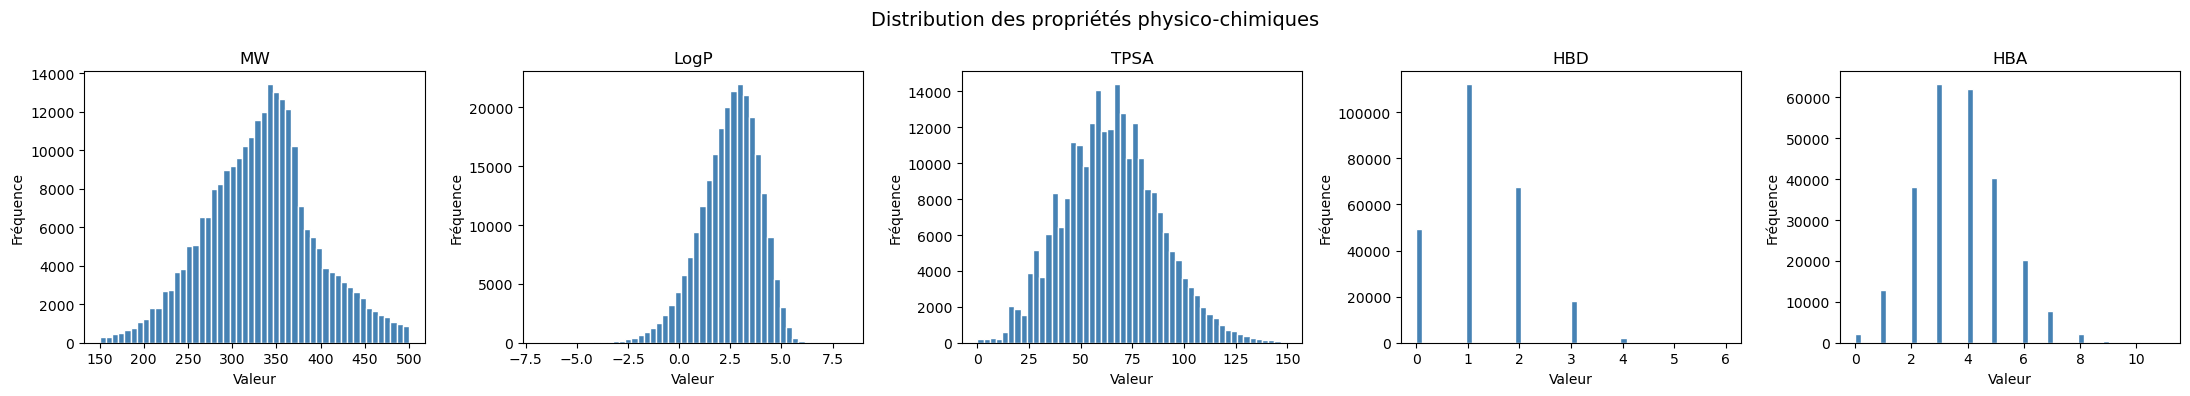

In [14]:
props = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA']
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
for i, p in enumerate(props):
    axes[i].hist(df_props[p], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(p, fontsize=12)
    axes[i].set_xlabel('Valeur')
    axes[i].set_ylabel('Fréquence')
plt.suptitle('Distribution des propriétés physico-chimiques', fontsize=14)
plt.tight_layout()
plt.show()

In [15]:
#Détection des outliers (boxplots)

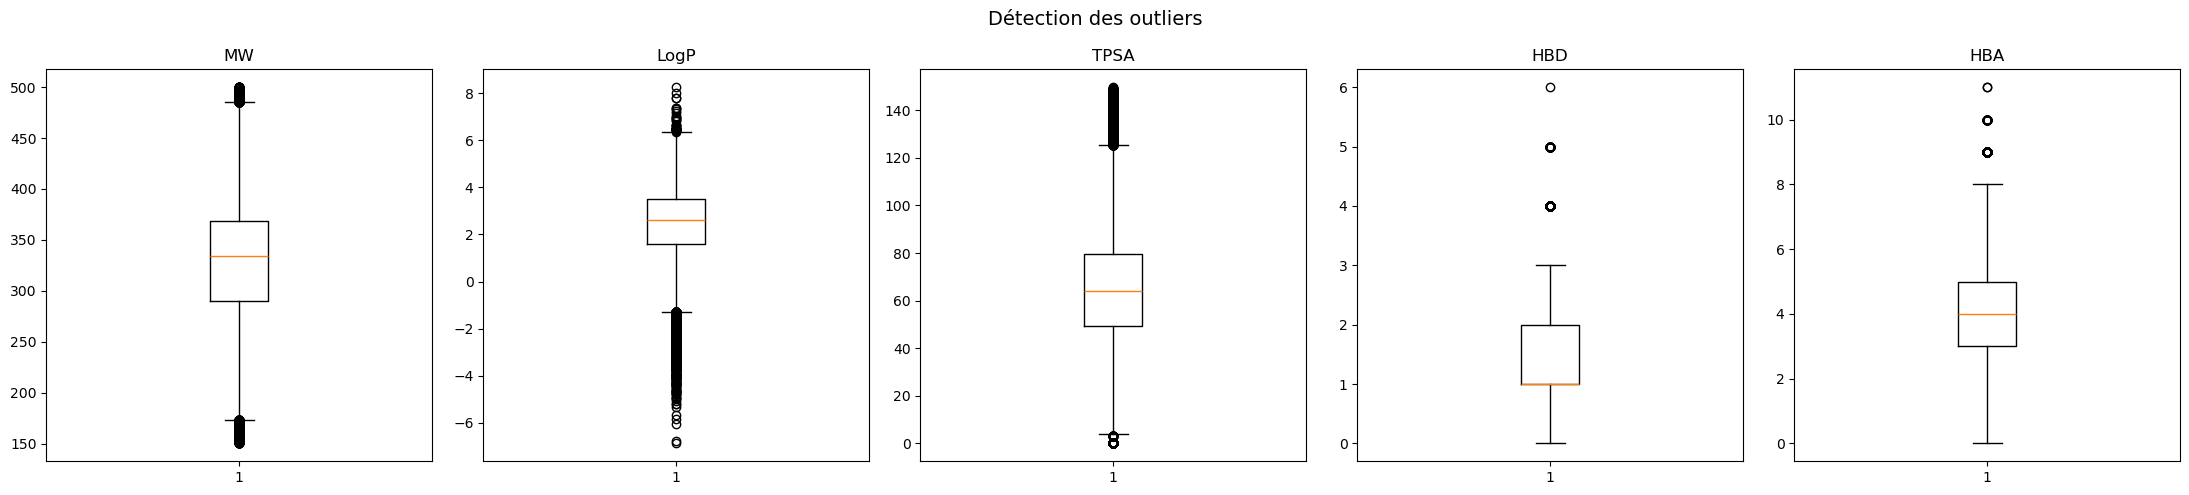

MW : 3218 outliers détectés
LogP : 3250 outliers détectés
TPSA : 2063 outliers détectés
HBD : 2089 outliers détectés
HBA : 454 outliers détectés


In [16]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
for i, p in enumerate(props):
    axes[i].boxplot(df_props[p].dropna())
    axes[i].set_title(p)
plt.suptitle('Détection des outliers', fontsize=14)
plt.tight_layout()
plt.show()
# Compter les outliers par propriété (méthode IQR)
for p in props:
    Q1, Q3 = df_props[p].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    outliers = df_props[(df_props[p] < Q1 - 1.5*IQR) | (df_props[p] > Q3 + 1.5*IQR)]
    print(f'{p} : {len(outliers)} outliers détectés')

In [17]:
#Heatmap des corrélations

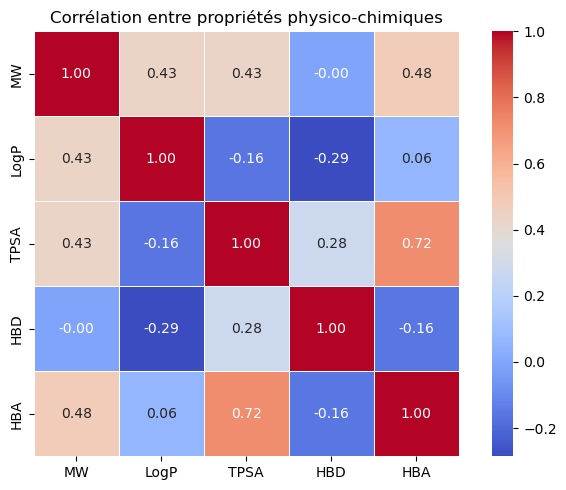

In [18]:
plt.figure(figsize=(7, 5))
corr = df_props[props].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Corrélation entre propriétés physico-chimiques')
plt.tight_layout()
plt.show()

In [19]:
#Visualisation de molécules en 2D

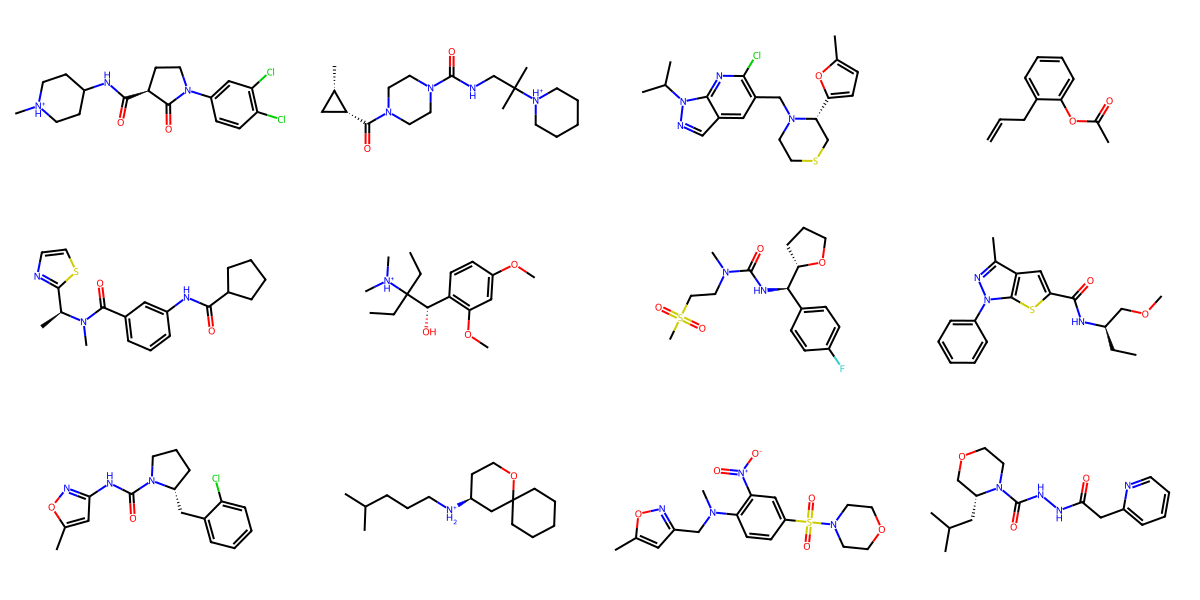

In [20]:
from rdkit.Chem import Draw
sample_smiles = df['smiles'].sample(12, random_state=42).tolist()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles if Chem.MolFromSmiles(s)]
img = Draw.MolsToGridImage(mols[:12], molsPerRow=4, subImgSize=(300, 200))
img

In [21]:
#pretraitemnet 

In [22]:
#Nettoyage des SMILES

In [23]:
# Supprimer les SMILES invalides et les doublons

In [24]:
import pandas as pd
from rdkit import Chem
df = pd.read_csv('250k_rndm_zinc_drugs_clean_3.csv')
def clean_smiles(df, col='smiles'):
    cleaned, invalides = [], 0
    for smi in df[col]:
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            invalides += 1
            continue
        cleaned.append(Chem.MolToSmiles(mol, canonical=True))
    cleaned = list(set(cleaned))
    print(f'Invalides : {invalides} | Doublons supprimés')
    return pd.DataFrame({'smiles': cleaned})
df_clean = clean_smiles(df)
print(f'Avant : {len(df)} | Après : {len(df_clean)}')

Invalides : 0 | Doublons supprimés
Avant : 249455 | Après : 249455


In [25]:
# Suppression des outliers

In [26]:
from rdkit.Chem import Descriptors, rdMolDescriptors
def calculate_properties(df):
    records = []
    for smi in df['smiles']:
        mol = Chem.MolFromSmiles(smi)
        if mol is None: continue
        records.append({'smiles': smi,
                        'MW'  : Descriptors.MolWt(mol),
                        'LogP': Descriptors.MolLogP(mol),
                        'TPSA': Descriptors.TPSA(mol),
                        'HBD' : rdMolDescriptors.CalcNumHBD(mol),
                        'HBA' : rdMolDescriptors.CalcNumHBA(mol)})
    return pd.DataFrame(records)
df_props = calculate_properties(df_clean)
def remove_outliers(df, cols):
    mask = pd.Series([True] * len(df))
    for col in cols:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        mask = mask & (df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)
    return df[mask.values]
props = ['MW', 'LogP', 'TPSA', 'HBD', 'HBA']
df_no_outliers = remove_outliers(df_props, props)
print(f'Après suppression outliers : {len(df_no_outliers)}')

Après suppression outliers : 239320


In [27]:
#Filtre de Lipinski (règle des 5)

In [28]:
df_lipinski = df_no_outliers[
    (df_no_outliers['MW']   <= 500) &
    (df_no_outliers['LogP'] <= 5)   &
    (df_no_outliers['HBD']  <= 5)   &
    (df_no_outliers['HBA']  <= 10)
]
print(f'Molécules drug-like : {len(df_lipinski)} / {len(df_no_outliers)}')

Molécules drug-like : 235652 / 239320


In [29]:
#normalisation des propriétés

In [30]:
from sklearn.preprocessing import StandardScaler
import joblib
scaler = StandardScaler()
df_scaled = df_lipinski.copy()
df_scaled[props] = scaler.fit_transform(df_lipinski[props])
joblib.dump(scaler,'scaler.pkl')
print('Propriétés après normalisation :')
df_scaled[props].describe().round(3)

Propriétés après normalisation :


,MW,LogP,TPSA,HBD,HBA
count,235652.000,235652.000,235652.000,235652.000,235652.000
mean,0.000,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000
min,-2.693,-2.910,-2.745,-1.444,-2.483
25%,-0.677,-0.658,-0.701,-0.256,-0.458
50%,0.036,0.100,-0.014,-0.256,0.216
75%,0.613,0.750,0.676,0.932,0.891
max,2.653,1.940,2.800,2.119,2.916


In [31]:
# Encodage SMILES 

In [32]:
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import numpy as np

generator = GetMorganGenerator(radius=2, fpSize=2048)

def smiles_to_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None: return None
    fp = generator.GetFingerprintAsNumPy(mol)
    return fp

fingerprints, valid_smiles = [], []
for smi in df_lipinski['smiles']:
    fp = smiles_to_fingerprint(smi)
    if fp is not None:
        fingerprints.append(fp)
        valid_smiles.append(smi)

X = np.array(fingerprints)
print(f'Shape des fingerprints : {X.shape}')
np.save('fingerprints.npy', X)

Shape des fingerprints : (235652, 2048)


In [33]:
#Sélection de features (corrélations > 0.9)

In [34]:
#Supprimer les propriétés redondantes

In [35]:
corr_matrix = df_lipinski[props].corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print(f'Features supprimées (corrélation > 0.9) : {to_drop}')
df_final = df_lipinski.drop(columns=to_drop)
print(f'Features restantes : {df_final.columns.tolist()}')

Features supprimées (corrélation > 0.9) : []
Features restantes : ['smiles', 'MW', 'LogP', 'TPSA', 'HBD', 'HBA']


In [36]:
# Split Train / Test

In [37]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df_lipinski, test_size=0.2, random_state=42)
print(f'Train : {len(train_df)} molécules')
print(f'Test  : {len(test_df)} molécules')

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)
df_lipinski.to_csv('molecules_final.csv', index=False)
print('Datasets sauvegardés !')

Train : 188521 molécules
Test  : 47131 molécules
Datasets sauvegardés !


In [38]:
#configuration de l'API

In [39]:
import requests, pandas as pd, numpy as np, time

import os; API_KEY = os.environ.get('NVIDIA_API_KEY', 'METTRE_VOTRE_CLE_ICI')
BASE_URL = 'https://health.api.nvidia.com/v1/biology/nvidia/molmim/generate'
headers  = {'Authorization': f'Bearer {API_KEY}',
            'Content-Type': 'application/json'}

# Test avec l'aspirine
payload = {
    "smi": "CC(=O)Oc1ccccc1C(=O)O",
    "num_molecules": 3,
    "algorithm": "CMA-ES"
}

r = requests.post(BASE_URL, headers=headers, json=payload)
print('Status:', r.status_code)
print(r.json())

Status: 200
{'molecules': '[{"sample": "CC(C)Oc1ccccc1C(=O)O", "score": 0.7749290146965723}, {"sample": "CC(C)Oc1ccccc1C(=O)O", "score": 0.7749290146965723}, {"sample": "CC(C)Oc1ccccc1C(=O)O", "score": 0.7749290146965723}]', 'score_type': 'QED'}


In [40]:
#Encodage batch des molécules

In [41]:
import json

df_train = pd.read_csv('train.csv')
smiles_list = df_train['smiles'].sample(1000, random_state=42).tolist()

def encode_batch(smiles_list):
    results = []
    for i, smi in enumerate(smiles_list):
        try:
            payload = {
                "smi": smi,
                "num_molecules": 3,
                "algorithm": "CMA-ES"
            }
            r = requests.post(BASE_URL, headers=headers, json=payload, timeout=30)
            data = r.json()
            if 'molecules' in data:
                mols = json.loads(data['molecules'])
                for mol in mols:
                    smiles_gen = mol.get('sample', '')
                    score      = mol.get('score', None)
                    if smiles_gen:
                        results.append({
                            'smiles'        : smiles_gen,
                            'score_QED'     : score,
                            'source_smiles' : smi
                        })
        except Exception as e:
            print(f'Erreur molécule {i}: {e}')
        time.sleep(0.3)
        if i % 100 == 0:
            print(f'{i}/{len(smiles_list)} traités')
    return results

results = encode_batch(smiles_list)
df_gen = pd.DataFrame(results)
df_gen.to_csv('generated_molecules.csv', index=False)
print(f'✅ Molécules générées : {len(df_gen)}')
df_gen.head(10)

0/1000 traités
100/1000 traités
200/1000 traités
300/1000 traités
400/1000 traités
500/1000 traités
600/1000 traités
700/1000 traités
800/1000 traités
900/1000 traités
✅ Molécules générées : 3000


,smiles,score_QED,source_smiles
0,COC(=O)[C@@H]1CN(c2ccnc(C(N)=O)c2)C[C@@H]1c1cc...,0.862588,COC(=O)[C@H]1CN(c2ccnc(C(N)=O)c2)C[C@H]1C
1,COC(=O)[C@@H]1CN(c2ccnc(C(N)=O)c2)C[C@H]1c1ccccc1,0.862588,COC(=O)[C@H]1CN(c2ccnc(C(N)=O)c2)C[C@H]1C
2,COC(=O)[C@@H]1CN(c2ccnc(C(N)=O)c2)C[C@H]1c1ccccc1,0.862588,COC(=O)[C@H]1CN(c2ccnc(C(N)=O)c2)C[C@H]1C
3,COC(=O)c1ccc(N2CCN(c3ccccc3Cl)CC2)cc1,0.806941,COC(=O)c1ccc(N2CCN(c3ccccc3Cl)CC2)[nH+]c1
4,COC(=O)c1ccc(N2CCN(c3ccccc3Cl)CC2)cc1,0.806941,COC(=O)c1ccc(N2CCN(c3ccccc3Cl)CC2)[nH+]c1
5,COC(=O)c1ccc(N2CCN(c3ccccc3Cl)CC2)cc1,0.806941,COC(=O)c1ccc(N2CCN(c3ccccc3Cl)CC2)[nH+]c1
6,Cc1ccc(C(C)(C)C(=O)O[C@@H](CO)c2ccccn2)cc1,0.862379,Cc1ccc(C(C)(C)C(=O)O[C@H](C)c2ccccn2)cc1
7,Cc1ccc(C(C)(C)C(=O)O[C@@H](C(N)=O)c2ccccn2)cc1,0.859651,Cc1ccc(C(C)(C)C(=O)O[C@H](C)c2ccccn2)cc1
8,Cc1ccc(C(C)(C)C(=O)O[C@@H](C(=O)O)c2ccccn2)cc1,0.858596,Cc1ccc(C(C)(C)C(=O)O[C@H](C)c2ccccn2)cc1
9,COc1cc(-c2n[nH]cc2C(=O)N2CCC(C)CC2)cc(OC)c1OC,0.888063,COc1cc(-c2n[nH]cc2C[NH+]2CCN(c3cccc(C)[nH+]3)C...


In [ ]:
# Visualisation 2D de molécules
from rdkit.Chem import Draw

sample_smiles = df['smiles'].sample(12, random_state=42).tolist()
mols = [Chem.MolFromSmiles(s) for s in sample_smiles if Chem.MolFromSmiles(s)]
img = Draw.MolsToGridImage(mols[:12], molsPerRow=4, subImgSize=(300, 200))
img.save('molecules_sample.png')
img

In [44]:
# Sauvegarder le scaler
import joblib
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler sauvegardé")

✅ Scaler sauvegardé


In [45]:
# Évaluation & Métriques

In [46]:
train_set  = set(train_df['smiles'].tolist())
gen_smiles = df_gen['smiles'].dropna().tolist()

def compute_metrics(gen_smiles, train_set):
    valid  = [s for s in gen_smiles if Chem.MolFromSmiles(s) is not None]
    unique = list(set(valid))
    novel  = [s for s in unique if s not in train_set]
    return {
        'Validité (%)'  : round(len(valid)  / len(gen_smiles) * 100, 2),
        'Unicité (%)'   : round(len(unique) / len(valid)      * 100, 2) if valid  else 0,
        'Nouveauté (%)' : round(len(novel)  / len(unique)     * 100, 2) if unique else 0,
        'N valides'     : len(valid),
        'N uniques'     : len(unique),
        'N nouvelles'   : len(novel),
    }

metrics = compute_metrics(gen_smiles, train_set)
for k, v in metrics.items():
    print(f"  {k:20s} : {v}")

summary = pd.DataFrame([
    {'Métrique': 'Validité (%)',  'Notre modèle': metrics['Validité (%)'],  'Référence VAE': 97.7},
    {'Métrique': 'Unicité (%)',   'Notre modèle': metrics['Unicité (%)'],   'Référence VAE': 67.5},
    {'Métrique': 'Nouveauté (%)','Notre modèle': metrics['Nouveauté (%)'], 'Référence VAE': 100.0},
])
summary.to_csv('metrics_summary.csv', index=False)
print(summary.to_string(index=False)) 

  Validité (%)         : 100.0
  Unicité (%)          : 69.43
  Nouveauté (%)        : 95.3
  N valides            : 3000
  N uniques            : 2083
  N nouvelles          : 1985
     Métrique  Notre modèle  Référence VAE
 Validité (%)        100.00           97.7
  Unicité (%)         69.43           67.5
Nouveauté (%)         95.30          100.0
